In [1]:
#pip install lightgbm

### Exploratory Data Analysis (EDA):

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('diabetes.csv')

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data.rename(columns={'DiabetesPedigreeFunction': 'DPF'}, inplace=True)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   DPF            768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
data.isnull().sum()

Pregnancies      0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
DPF              0
Age              0
Outcome          0
dtype: int64

#### Visualization:

#### 1. Histogram :

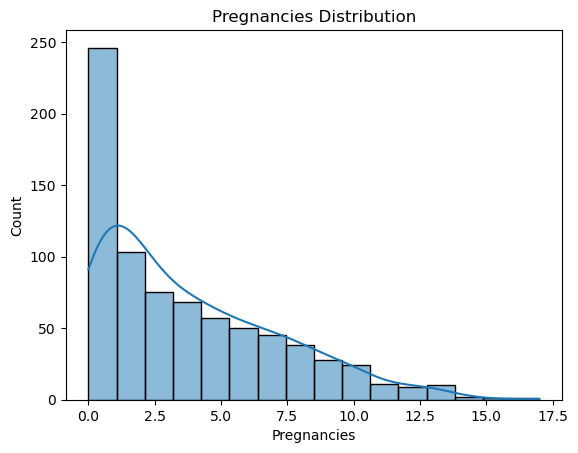

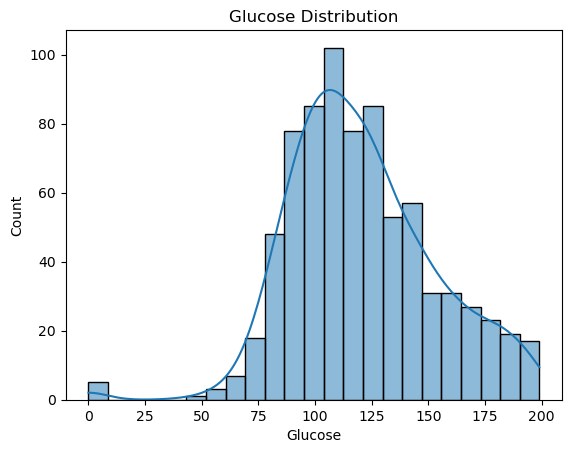

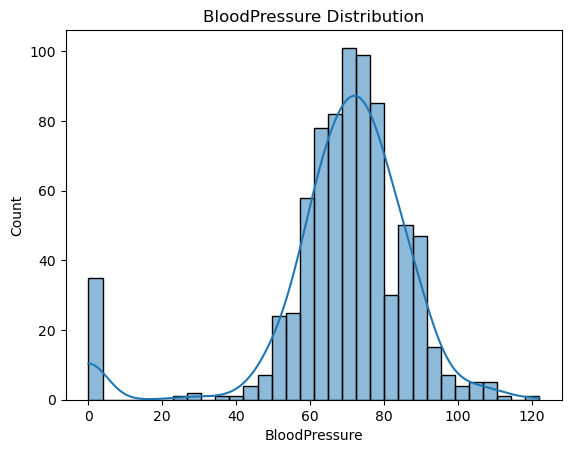

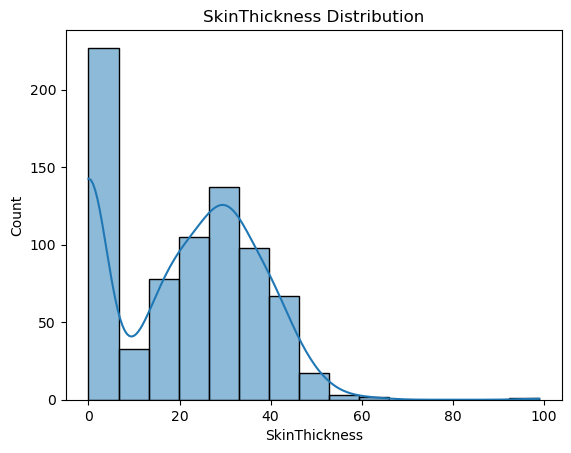

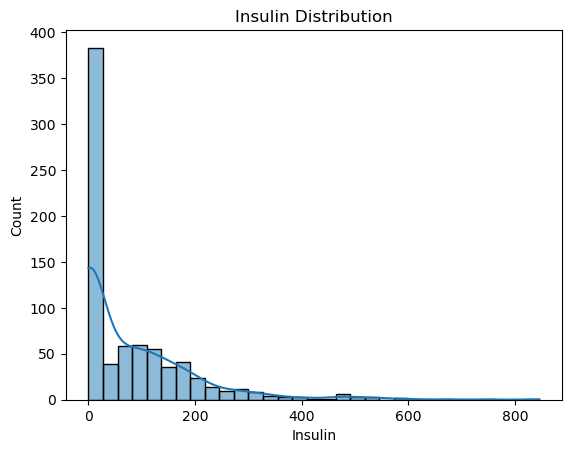

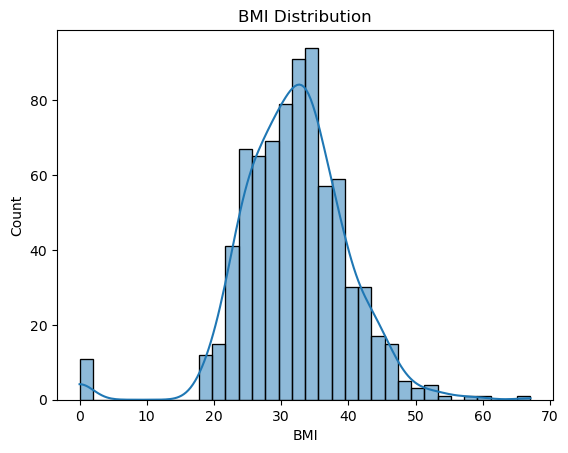

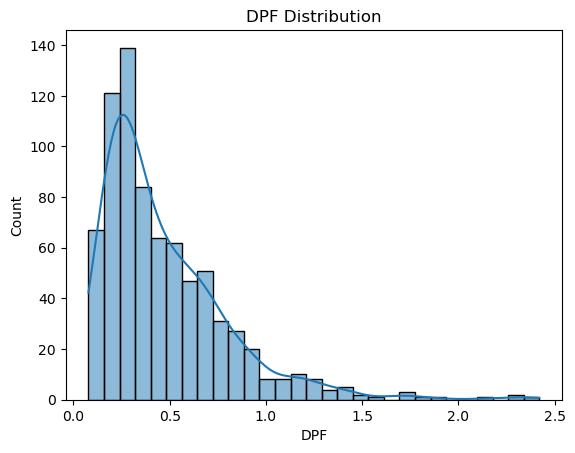

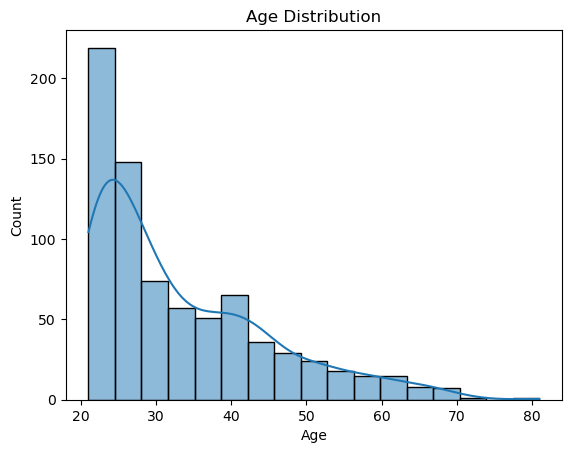

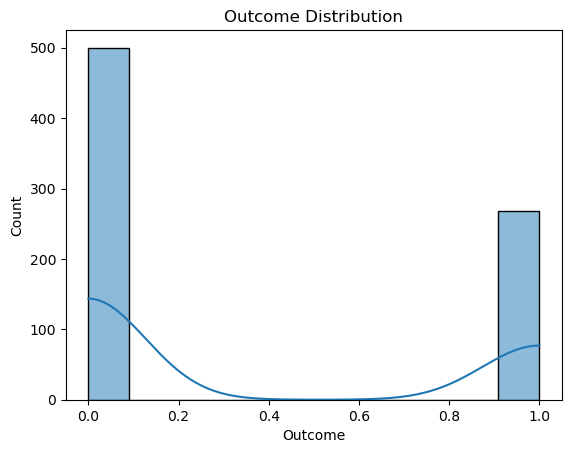

In [8]:
for col in data.columns :
    sns.histplot(data[col],kde=True)
    plt.title(f'{col} Distribution')
    plt.show()  

In [9]:
for col in data.columns :
    print(f'Skewness of {col}', data[col].skew())

Skewness of Pregnancies 0.9016739791518588
Skewness of Glucose 0.17375350179188992
Skewness of BloodPressure -1.8436079833551302
Skewness of SkinThickness 0.10937249648187608
Skewness of Insulin 2.272250858431574
Skewness of BMI -0.42898158845356543
Skewness of DPF 1.919911066307204
Skewness of Age 1.1295967011444805
Skewness of Outcome 0.635016643444986


#### Boxplot with Outliers :

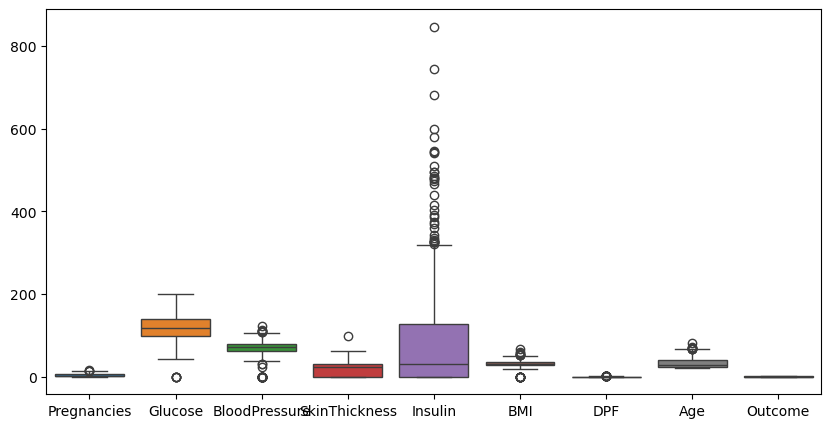

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(data)
plt.show()

In [11]:
for col in data.columns :
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + IQR*1.5
    lower_bound = Q1 - IQR*1.5
    outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    print(f'Outliers in {col} :',outliers.shape[0])

Outliers in Pregnancies : 4
Outliers in Glucose : 5
Outliers in BloodPressure : 45
Outliers in SkinThickness : 1
Outliers in Insulin : 34
Outliers in BMI : 19
Outliers in DPF : 29
Outliers in Age : 9
Outliers in Outcome : 0


In [12]:
for col in data.columns :
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + IQR*1.5
    lower_bound = Q1 - IQR*1.5
    data[col] = data[col].clip(upper_bound,lower_bound)

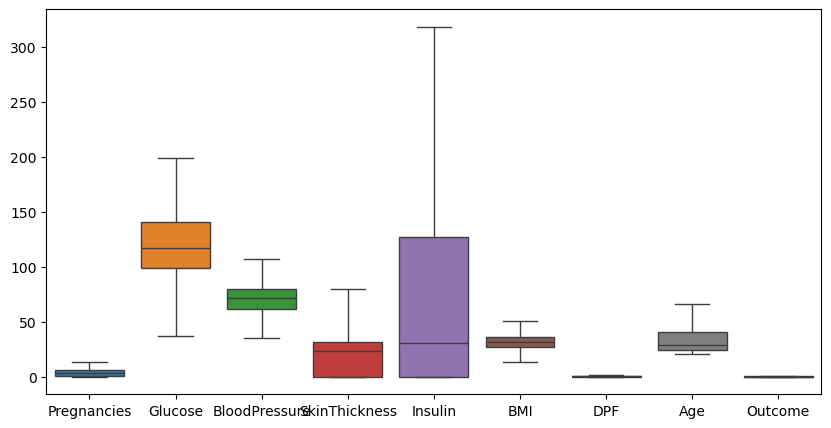

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data)
plt.show()

#### 3. Scatter Plots :

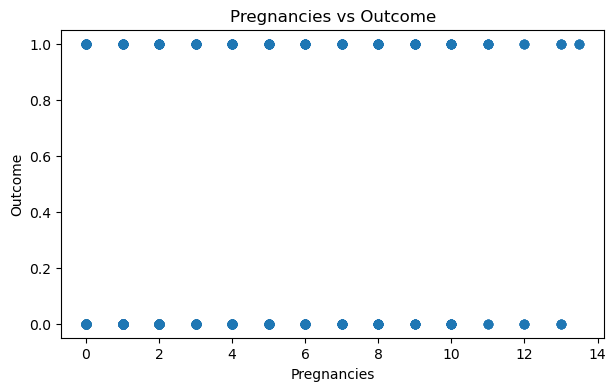

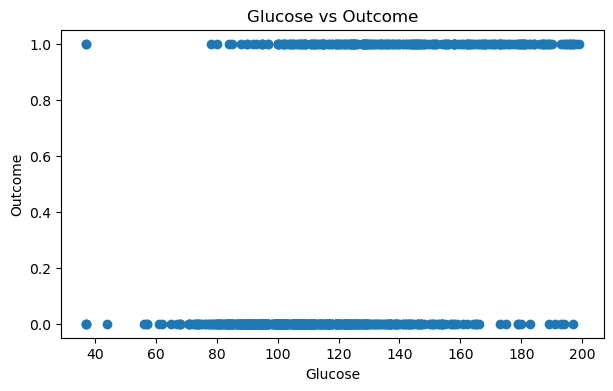

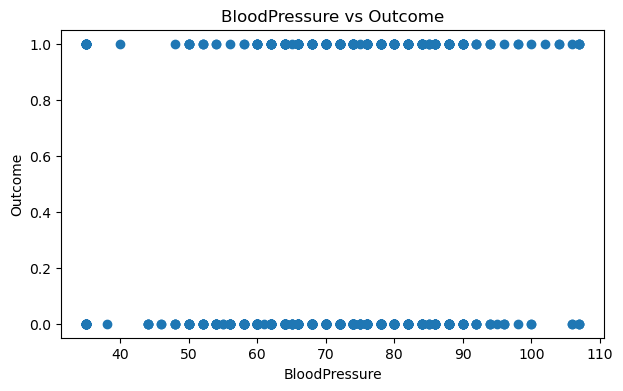

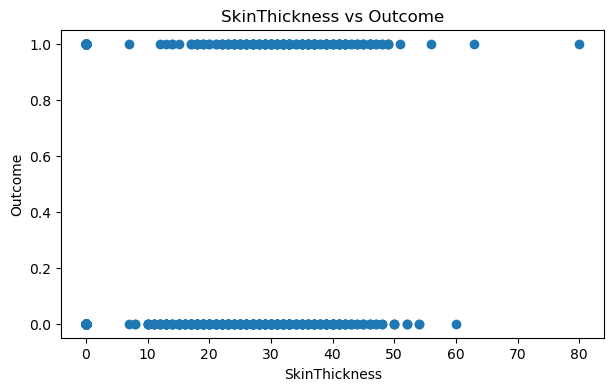

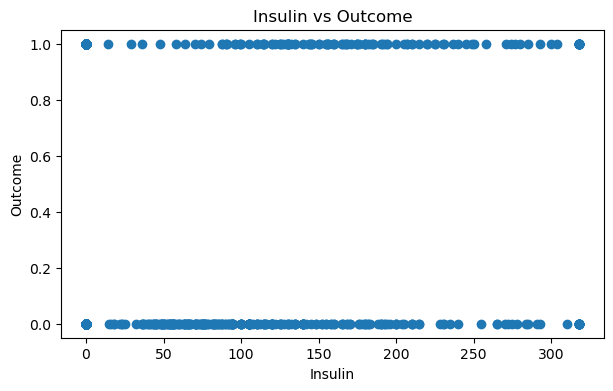

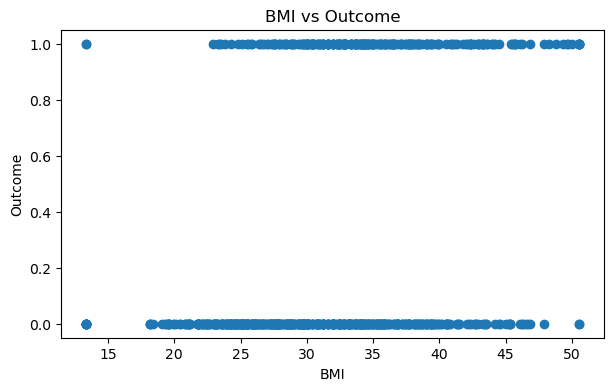

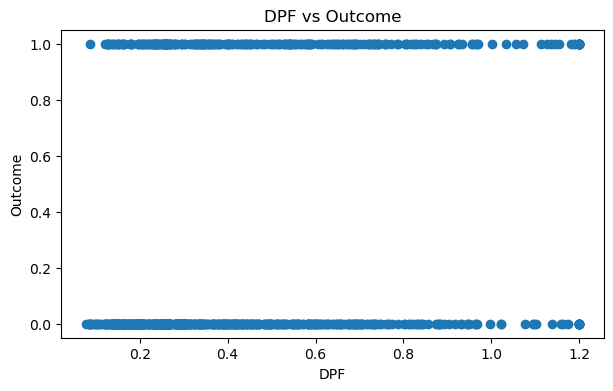

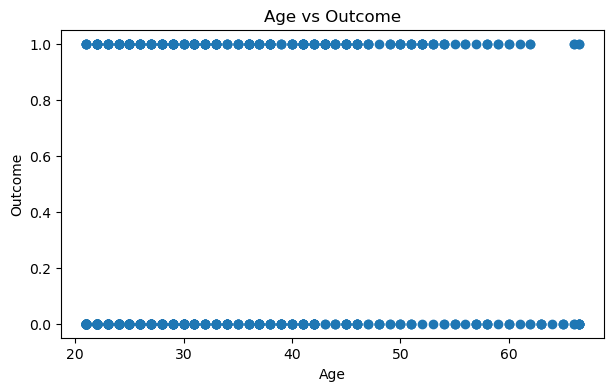

In [14]:
features = data.drop('Outcome', axis=1).columns

for col in features:
    plt.figure(figsize=(7,4))
    plt.scatter(data[col], data['Outcome'])
    plt.xlabel(col)
    plt.ylabel("Outcome")
    plt.title(f"{col} vs Outcome")
    plt.show()

#### 4. Bar Plot :

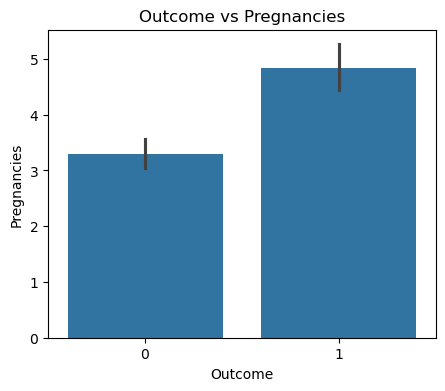

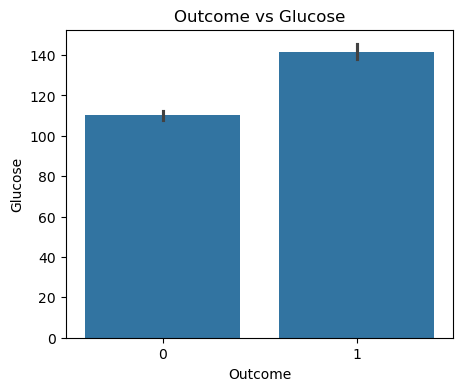

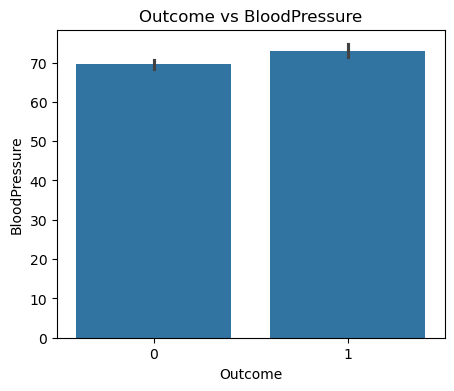

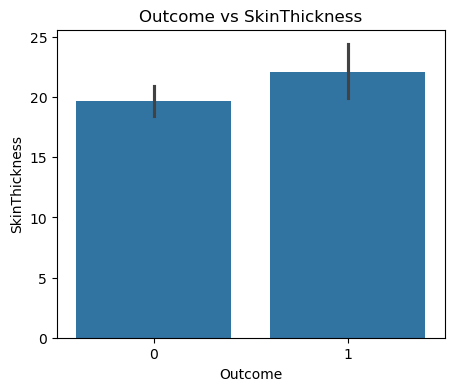

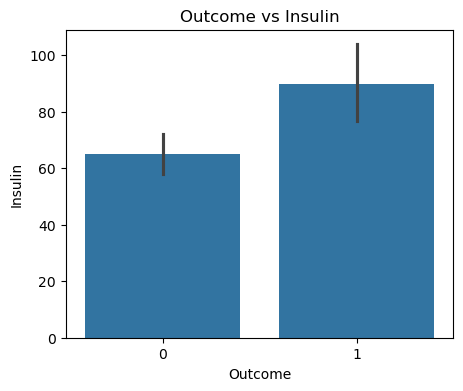

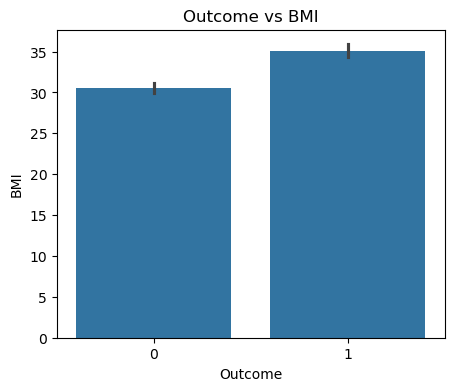

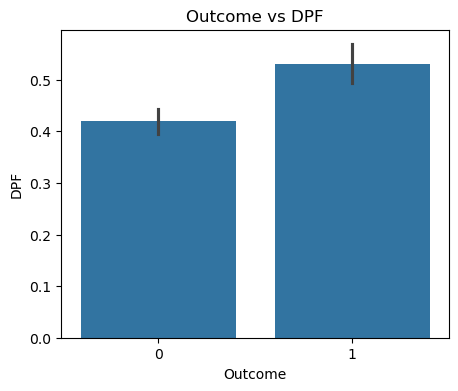

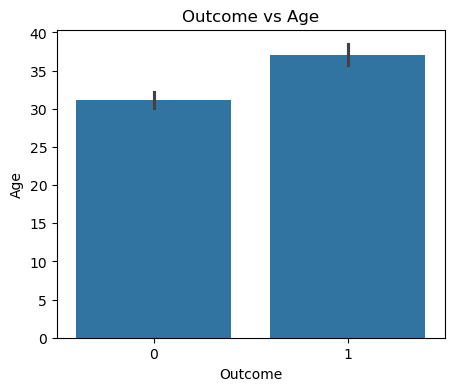

In [15]:
for col in features:
    plt.figure(figsize=(5,4))
    sns.barplot(x='Outcome', y=col, data=data)
    plt.title(f"Outcome vs {col}")
    plt.show()

### 2. Data Preprocessing:

#### - No Missing Value soo no need of imutation, For outliers we replace value with upper bound and lower bounds.
#### - All attributes are numeric soo no need of encoding.
#### - For LGBM and XGBM no need of scalling

### 3. Building Predictive Models:

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X = data.drop('Outcome',axis=1)
y = data['Outcome']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((614, 8), (154, 8), (614,), (154,))

#### XGBoost Model :

In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier()

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        99
           1       0.59      0.65      0.62        55

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.72      0.71      0.72       154



#### LightGBM Model :

In [21]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 652
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

#### Cross Validation

In [22]:
from sklearn.model_selection import cross_val_score

xgb_cv = cross_val_score(xgb, X, y, cv=5).mean()
lgbm_cv = cross_val_score(lgbm, X, y, cv=5).mean()

print("XGB CV Score:", xgb_cv)
print("LGBM CV Score:", lgbm_cv)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

##### XGB CV Score: 0.7383244206773618
##### LGBM CV Score: 0.7409048467871997


#### Comparison Graph :

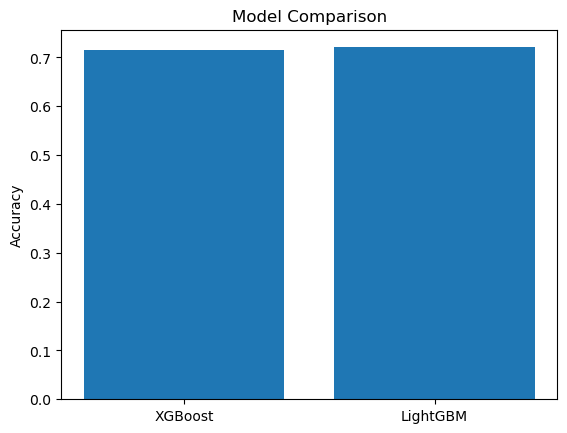

In [23]:
models = ['XGBoost', 'LightGBM']
scores = [accuracy_score(y_test, y_pred_xgb),
          accuracy_score(y_test, y_pred_lgbm)]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

#### - Based on the comparison, LightGBM achieved marginally higher accuracy than XGBoost on the diabetes dataset.
#### - This suggests that LightGBM may be more efficient for this problem. However, XGBoost remains a strong and reliable model.
#### - Therefore, both algorithms are suitable, and the final choice depends on performance requirements and computational efficiency.

### Comparative Analysis :

#### 1. Performance Metrics Comparison :

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# XGBoost metrics
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_pre = precision_score(y_test, y_pred_xgb)
xgb_rec = recall_score(y_test, y_pred_xgb)

# LightGBM metrics
lgb_acc = accuracy_score(y_test, y_pred_lgbm)
lgb_pre = precision_score(y_test, y_pred_lgbm)
lgb_rec = recall_score(y_test, y_pred_lgbm)

print("XGBoost -> Accuracy:", xgb_acc, "Precision:", xgb_pre, "Recall:", xgb_rec)
print("LightGBM -> Accuracy:", lgb_acc, "Precision:", lgb_pre, "Recall:", lgb_rec)

XGBoost -> Accuracy: 0.7142857142857143 Precision: 0.5901639344262295 Recall: 0.6545454545454545
LightGBM -> Accuracy: 0.7207792207792207 Precision: 0.5909090909090909 Recall: 0.7090909090909091


#### 2. Visualization (Bar Chart) :

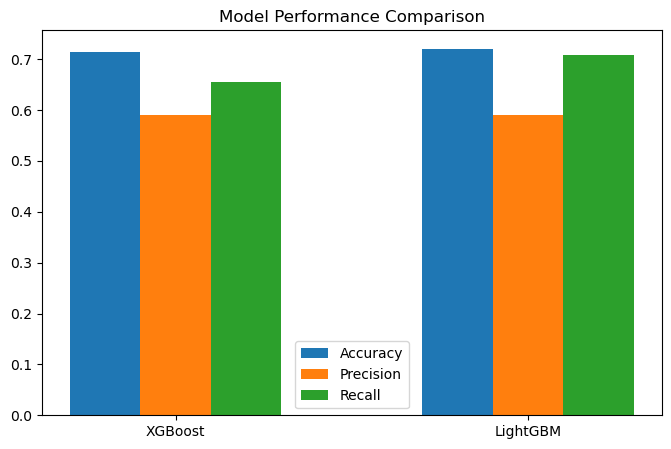

In [26]:
import matplotlib.pyplot as plt

models = ['XGBoost', 'LightGBM']
accuracy = [xgb_acc, lgb_acc]
precision = [xgb_pre, lgb_pre]
recall = [xgb_rec, lgb_rec]

x = range(len(models))

plt.figure(figsize=(8,5))

plt.bar(x, accuracy, width=0.2, label='Accuracy')
plt.bar([i+0.2 for i in x], precision, width=0.2, label='Precision')
plt.bar([i+0.4 for i in x], recall, width=0.2, label='Recall')

plt.xticks([i+0.2 for i in x], models)
plt.title("Model Performance Comparison")
plt.legend()

plt.show()

#### 3. Interpretation :

##### The performance of LightGBM and XGBoost models was evaluated using accuracy, precision, and recall metrics. Both models performed well on the dataset, showing strong predictive capability.

##### Accuracy: LightGBM achieved slightly higher accuracy compared to XGBoost, indicating better overall prediction performance.
##### Precision: Both models showed similar precision, meaning they are equally good at minimizing false positives.
##### Recall: LightGBM demonstrated slightly better recall, indicating it is more effective in identifying positive cases.

#### 4. Strengths & Weaknesses :

#### LightGBM :

Strengths:
- Faster training speed
- Higher accuracy in this dataset
- Efficient for large datasets

Weaknesses:
- Can overfit on small datasets
- Sensitive to noise

#### XGBoost :

Strengths:

- More stable and robust
- Better handling of overfitting
- Strong regularization

Weaknesses:

- Slower compared to LightGBM
- Slightly lower accuracy here

#### Conclusion :

##### Based on the comparative analysis, LightGBM slightly outperformed XGBoost in terms of accuracy and recall, making it more suitable for this dataset.
However, XGBoost remains a reliable and robust model. 
The choice between the two depends on the specific problem, dataset size, and performance requirements.